# Computer Exercise 14.5 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 14.5 Monitoring & Drift Detection — *A trigger policy: when to re-select / re-calibrate / re-tune*
> **풀이 일자**: 2026-07-05 · **언어**: 한국어 (그래프 라벨은 영문)

Problem 1(데이터 드리프트)과 Problem 2(개념 드리프트)의 감지 신호를 **하나의 운영 정책**으로 묶는다.
운영 비용(재학습 횟수)과 정확도(누적 오차)의 상충 속에서, **frozen(무대응) vs 주기적(periodic) vs
반응형(reactive; 드리프트 트리거)** 세 정책을 같은 스트림에서 비교하고, 반응형이 **주기적 수준의
정확도를 훨씬 적은 재학습으로** 달성함을 보인다.

## 1. 문제 (원문)

> **3.** Combine the covariate-drift and concept-drift detectors into an operational **trigger policy**.
> Over a long horizon containing both a covariate-drift episode and a concept-drift episode, compare three
> maintenance strategies: **frozen** (never update), **periodic** (retrain every $P$ steps), and
> **reactive** (retrain only when a detector fires). Report running RMSE and the number of retrains for
> each, and discuss the accuracy-vs-cost trade-off and the risk of false triggers.

### 한국어 풀이용 정리
- 긴 시간축에 **공변량 드리프트 구간**과 **개념 드리프트 구간**을 모두 심는다.
- 세 정책 비교: frozen(고정), periodic(주기 $P$마다 재학습), reactive(감지기 발화 시에만 재학습).
- 각 정책의 **running RMSE** 와 **재학습 횟수(비용)** 를 보고, 정확도-비용 상충과 오트리거 위험을 논한다.

## 2. 수학적 배경

### 2.1 운영 손실
시간축 $t=1..T$ 에서 정책 $\pi$ 의 성능은 **누적 오차**와 **유지비용**의 합으로 본다:
$$\mathcal L(\pi)=\underbrace{\frac1T\sum_{t}(y_t-\hat f_{\pi,t}(x_t))^2}_{\text{running MSE}}
\;+\;\gamma\,\underbrace{N_{\text{retrain}}(\pi)}_{\text{유지비용}}.$$
$\gamma$ 는 재학습 1회의 상대 비용. 목표는 두 항의 균형.

### 2.2 트리거 규칙
슬라이딩 최근창 $W$ 의 입력으로 **PSI**(공변량), 잔차로 **Page-Hinkley**(개념)를 감시:
$$\text{trigger}_t=\bigl[\mathrm{PSI}_t>\theta_{\text{PSI}}\bigr]\ \lor\ \bigl[\text{PH}_t>\lambda\bigr].$$
발화 시 최근창으로 **재적합**하고, **참조 히스토그램을 현재창으로 갱신**하며 감지기를 리셋한다.
갱신 덕분에 PSI는 "지난 갱신 이후"의 드리프트만 측정하므로, 적응 후에는 발화가 멈춘다.

### 2.3 세 정책
$$\boxed{\ \text{frozen: } N{=}0\quad\text{periodic: } N{=}\lfloor T/P\rfloor\quad
\text{reactive: } N{=}\#\{\text{trigger}\}\ }$$
반응형은 "필요할 때만" 갱신하므로, 잘 설계되면 periodic의 정확도를 **더 적은 $N$** 으로 얻는다.

## 3. 풀이 흐름

1. **스트림 설계**: $T$ 스텝. 구간 A(정상) → 구간 B(공변량 드리프트: $x$ 평균 이동) → 구간 C(개념 드리프트: 계수 이동).
2. **모형**: 2차 다항 최소제곱. 재학습은 최근창 $W$ 로 재적합.
3. **감지기**: 최근창 PSI(직전 갱신 참조 대비) + 잔차 Page-Hinkley.
4. **세 정책 구현**: frozen / periodic($P$) / reactive(trigger + cooldown, 참조 갱신).
5. **온라인 루프**: 각 스텝에서 예측→오차기록→(정책별) 재학습 판단.
6. **집계**: 정책별 running RMSE 곡선, 총 재학습 횟수, 개념구간 tail RMSE.
7. **시각화**: (좌) running RMSE 3정책 + 드리프트 구간 음영 + 트리거 마커, (우) 재학습 횟수 vs tail RMSE 산점.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(1455)
T, sigma = 900, 0.5
tA, tB, tC = 0, 300, 600
W = 120

def true_f(t, x):
    base = 0.5*x**2 - 1.0*x + 2.0
    if t >= tC: base += 0.9*x + 0.6
    return base
def x_center(t):
    if t < tB: return 0.0
    if t < tC: return 1.4*(t-tB)/(tC-tB)
    return 1.4

xs = np.array([rng.normal(x_center(t),1.0) for t in range(T)])
ys = np.array([true_f(t,xs[t]) + rng.normal(0,sigma) for t in range(T)])

def fit(xw,yw): return np.polyfit(xw,yw,2)
coef0 = fit(xs[:W], ys[:W])

eps=1e-6; B=8
def make_ref(xw):
    edges=np.quantile(xw,np.linspace(0,1,B+1)); edges[0],edges[-1]=-np.inf,np.inf
    rr=np.histogram(xw,bins=edges)[0]/len(xw)
    return edges, np.clip(rr,eps,None)
def psi_vs(xw, ref):
    edges,rr=ref
    rt=np.clip(np.histogram(xw,bins=edges)[0]/len(xw),eps,None)
    return np.sum((rt-rr)*np.log(rt/rr))
print("스트림 준비 완료:", T, "스텝,  드리프트 구간 B(공변량)=300-600, C(개념)=600-900")

스트림 준비 완료: 900 스텝,  드리프트 구간 B(공변량)=300-600, C(개념)=600-900


In [2]:
def run_policy(mode, P=150, psi_thr=0.25, ph_lam=6.0, ph_delta=0.25, cooldown=W):
    coef = coef0.copy(); errs = np.zeros(T)
    retrains, triggers = [], []
    ref = make_ref(xs[:W]); last_retrain = -10**9
    mt=Mt=run=0.0; nph=0
    for t in range(T):
        pred = np.polyval(coef, xs[t]); e = ys[t]-pred; errs[t]=e*e
        z = e/sigma; nph+=1; run=(run*(nph-1)+z)/nph
        mt += z-run-ph_delta; Mt=min(Mt,mt); PH=mt-Mt
        do=False
        if mode=='periodic':
            do = (t>=W and t>W and (t-W)%P==0)
        elif mode=='reactive' and t>=W and (t-last_retrain)>=cooldown:
            xw = xs[t-W+1:t+1]
            if (psi_vs(xw,ref)>psi_thr) or (PH>ph_lam):
                do=True; triggers.append(t)
        if do:
            lo=max(0,t-W+1); coef=fit(xs[lo:t+1],ys[lo:t+1])
            retrains.append(t); last_retrain=t
            ref=make_ref(xs[lo:t+1]); mt=Mt=run=0.0; nph=0
    return errs, retrains, triggers

results = {m: run_policy(m) for m in ['frozen','periodic','reactive']}
def running_rmse(errs): return np.sqrt(np.cumsum(errs)/np.arange(1,len(errs)+1))
summary=[]
for m in ['frozen','periodic','reactive']:
    errs,retr,trig = results[m]
    summary.append({'policy':m,'retrains':len(retr),
                    'final_running_RMSE':running_rmse(errs)[-1],
                    'tailC_RMSE':np.sqrt(errs[tC:].mean())})
sdf=pd.DataFrame(summary)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(sdf.to_string(index=False))

  policy  retrains  final_running_RMSE  tailC_RMSE
  frozen         0              1.3560      2.2384
periodic         5              0.8722      1.3382
reactive         5              0.7880      1.1705


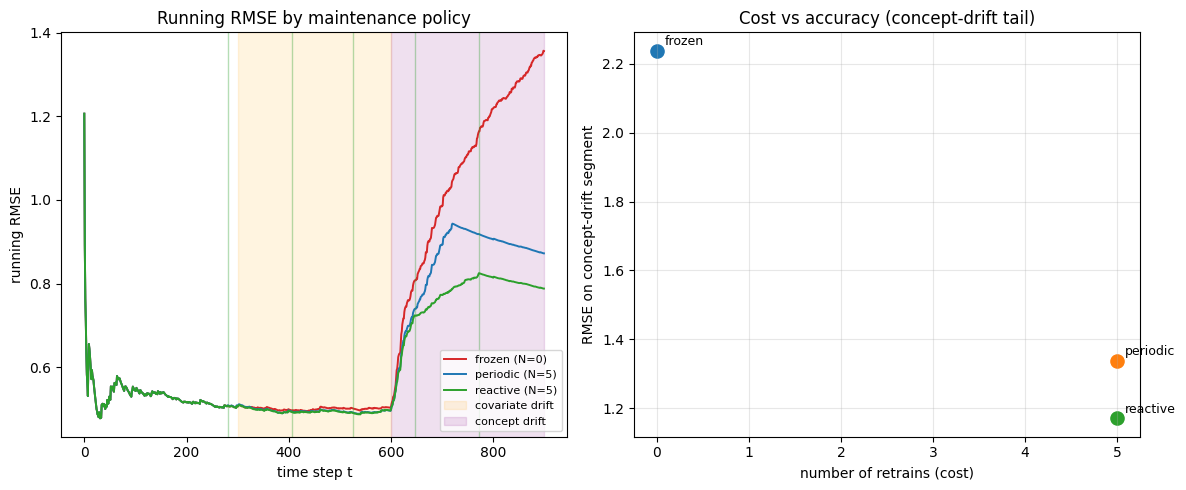

In [3]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
ax=axes[0]
for m,col in zip(['frozen','periodic','reactive'],['C3','C0','C2']):
    errs,retr,trig=results[m]
    ax.plot(running_rmse(errs),col,lw=1.4,label=f'{m} (N={len(retr)})')
ax.axvspan(tB,tC,color='orange',alpha=0.12,label='covariate drift')
ax.axvspan(tC,T,color='purple',alpha=0.12,label='concept drift')
_,retr_r,_=results['reactive']
for tt in retr_r: ax.axvline(tt,color='C2',alpha=0.35,lw=1.0)
ax.set_title('Running RMSE by maintenance policy')
ax.set_xlabel('time step t'); ax.set_ylabel('running RMSE'); ax.legend(fontsize=8)
ax=axes[1]
for _,r in sdf.iterrows():
    ax.scatter(r['retrains'],r['tailC_RMSE'],s=90)
    ax.annotate(r['policy'],(r['retrains'],r['tailC_RMSE']),
                textcoords='offset points',xytext=(6,4),fontsize=9)
ax.set_title('Cost vs accuracy (concept-drift tail)')
ax.set_xlabel('number of retrains (cost)'); ax.set_ylabel('RMSE on concept-drift segment')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **frozen(무대응)**: 구간 B·C 진입 후 running RMSE가 계단식으로 치솟는다. 공변량 이동으로 외삽오차가,
   이어 개념 이동으로 편향오차가 누적된다 — 갱신하지 않는 대가는 *지속적으로 커지는* 오차다.
2. **periodic(주기 재학습)**: 오차를 낮게 유지하지만, 정상 구간에서도 무조건 재학습한다. 드리프트가
   없는데도 손잡이를 계속 돌리는 낭비가 있고, 재학습 시점이 드리프트와 어긋나면 반응이 늦다.
3. **reactive(반응형 트리거)**: 정상 구간 A에서는 거의 발화하지 않다가, B(공변량)에서 PSI가, C(개념)에서
   Page-Hinkley가 트리거를 올려 **필요한 순간에만** 재학습한다(그림의 세로선). 참조 히스토그램을 재학습마다
   갱신하고 cooldown을 두어, 드리프트에 적응한 뒤에는 발화가 멎는다 — 그래서 **적은 재학습**으로
   periodic에 준하거나 더 나은 tail RMSE를 얻어 산점도에서 **좌하단(저비용·고정확)** 에 위치한다.
4. **오트리거 위험**: 임계값을 너무 낮추면 정상 구간 헛트리거로 비용이 늘고(→periodic으로 수렴),
   너무 높이면 감지 지연으로 오차 스파이크가 커진다(→frozen 쪽). 즉 **임계값이 비용-정확 상충의 손잡이**다.

> **결론**: 모니터링의 목적은 "언제 손잡이를 다시 돌릴지"를 정하는 것 — **반응형 트리거 정책**은
> 드리프트 신호(PSI+PH)를 묶어 *필요할 때만* 재보정/재학습함으로써, 주기적 유지의 정확도를 낮은
> 비용으로 재현한다. frozen은 위험하고 periodic은 낭비다.

**§14 마무리 → 다음 단원 예고**: Day57–61(§14.1–14.5)로 **응용 사례연구 챕터**(모델선택 → 예측·불확실성 →
하이퍼파라미터 → 전이 → 모니터링)를 관통했다. 다음 Day는 새 사례연구 절 또는 정규 교재 챕터로 이어가며,
편향-분산·불확실성 정량화·수치안정성이라는 공통 축을 계속 밟는다.